# This is an example Jupyter Notebook for CLIP experiments
In this example single dog image is processed and classified.

In [1]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

Check for cuda for faster use

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Detected device: {device.upper()}")

Detected device: CPU


In [ ]:
model, preprocess = clip.load("ViT-B/32", device=device)

image_path = Path.cwd().parent / "images" / "example" / "dog.png"
image = Image.open(image_path)

image_input = preprocess(image).unsqueeze(0).to(device) #type:ignore

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 73.5MiB/s]


In [4]:
labels = ["a diagram", "a dog", "a cat"]
text = clip.tokenize(labels).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

for label, prob in zip(labels, probs):
    print(f"- {label}: {prob * 100:.2f}%")

- a diagram: 0.53%
- a dog: 99.31%
- a cat: 0.15%


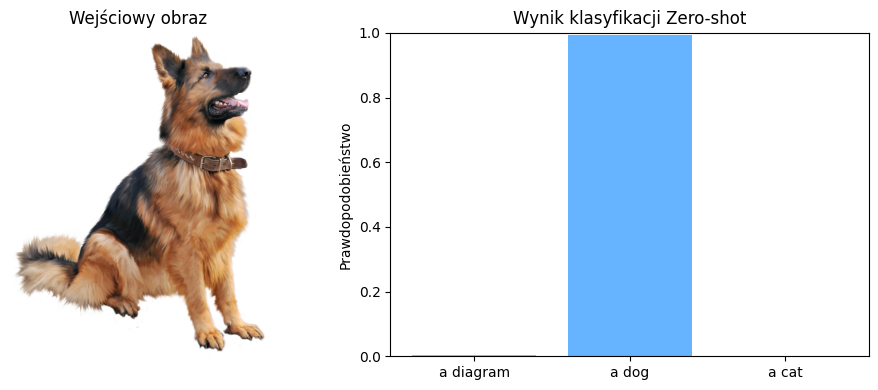

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(image)
ax1.set_title("Wejściowy obraz")
ax1.axis("off")

colors = ['#ff9999', '#66b3ff', '#99ff99']
ax2.bar(labels, probs, color=colors)
ax2.set_title("Wynik klasyfikacji Zero-shot")
ax2.set_ylabel("Prawdopodobieństwo")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("test_output.png")

plt.show()